# Система прогнозирования продаж для «Прилавка»


## Описание задачи

Клиент — компания «Прилавок», новая сеть дарксторов в России, специализирующаяся на быстрой доставке продуктов и товаров повседневного спроса. Компания работает с 2023 года и управляет более чем 45 дарксторами.

**Бизнес-проблема**

Эффективность дарксторов критически зависит от точности управления запасами. Текущая система планирования закупок работает на субъективных оценках аналитиков, что приводит к разным проблемам:
- К дефициту товаров в пиковые периоды (недополучение 3–5% выручки).
- К избыточным запасам и списаниям продуктов с коротким сроком годности (2–3% от выручки).
- К неэффективному использованию времени аналитиков (15–20 часов в неделю на ручное планирование).

**Цель проекта**

Разработать автоматизированную систему прогнозирования недельных продаж для каждого отдела во всех дарксторах с использованием машинного обучения (модель CatBoost). Система будет работать в режиме пакетного внедрения с недельным циклом: модель будет переобучаться каждое воскресенье вечером, а к понедельнику утром прогнозы будут готовы для передачи в систему планирования закупок.

## Описание данных

Для работы доступны исторические данные о продажах за февраль 2023 — октябрь 2025, организованные в виде нескольких таблиц в PostgreSQL:

1. Таблица `sales` — исторические данные о продажах:
   - `Store` — номер даркстора (1–45).
   - `Dept` — номер отдела внутри даркстора (1–99).
   - `Date` — неделя (дата начала недели).
   - `Weekly_Sales` — недельные продажи (руб., целевая переменная).
   - `IsHoliday` — признак праздничной недели.

2. Таблица `stores` — информация о дарксторах:
   - `Store` — номер даркстора.
   - `Type` — тип даркстора (A, B, C).
   - `Size` — размер даркстора в условных единицах.

3. Таблица `features` — внешние факторы:
   - `Store`, `Date` — идентификаторы.
   - `Temperature` — средняя температура за неделю.
   - `Fuel_Price` — средняя цена бензина.
   - `MarkDown1-5` — факторы рекламных акций и скидок.
   - `CPI` — индекс потребительских цен.
   - `Unemployment` — уровень безработицы.

4. Таблица `plan` — данные для инференса (ноябрь 2025 — июль 2026), содержит те же столбцы, что и `sales`, кроме `Weekly_Sales`.

## План работы

Проект состоит из двух частей. В этом ноутбуке вы выполните первую:

1. Первичный анализ и очистка данных.
2. Предобработка и создание признаков.
3. Мониторинг стабильности признаков (PSI).
4. Обучение модели CatBoost и оценка качества.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
from catboost import CatBoostRegressor
from phik import phik_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


load_dotenv()
from utils import (
    create_temporal_features,
    create_avg_sales_feature,
    create_lag_features,
    create_rolling_features,
    calculate_psi,
    interpret_psi
)
import warnings
warnings.filterwarnings("ignore")

Фиксируем `random_state` для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

### Шаг 1. Первичный анализ данных

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME')
)

engine = create_engine(connection_string)

In [4]:
query_sales = """
SELECT *
FROM public.sales
"""

sales_df = pd.read_sql_query(query_sales, con=engine)
sales_df.head()

,store,dept,date,weekly_sales,is_holiday
0,1,1,2023-02-05,24924.50,False
1,29,5,2023-02-05,15552.08,False
2,29,6,2023-02-05,3200.22,False
3,29,7,2023-02-05,10820.05,False
4,29,8,2023-02-05,20055.64,False


In [5]:
query_stores = """
SELECT *
FROM public.stores
"""

stores_df = pd.read_sql_query(query_stores, con=engine)
stores_df.head()

,store,type,size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
query_features = """
SELECT *
FROM public.features
"""

features_df = pd.read_sql_query(query_features, con=engine)
features_df.head()

,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,NaN,NaN,NaN,NaN,211.096358,8.106
1,29,5,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
2,29,6,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
3,29,7,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
4,29,8,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064


In [7]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   weekly_sales  421570 non-null  float64
 4   is_holiday    421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [8]:
stores_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   store   45 non-null     int64
 1   type    45 non-null     str  
 2   size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


In [9]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   temperature   421570 non-null  float64
 4   fuel_price    421570 non-null  float64
 5   factor1       421570 non-null  float64
 6   factor2       111248 non-null  float64
 7   factor3       137091 non-null  float64
 8   factor4       134967 non-null  float64
 9   factor5       151432 non-null  float64
 10  cpi           421570 non-null  float64
 11  unemployment  421570 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 38.6+ MB


In [10]:
print("Sales - Дубликаты:", sales_df.duplicated().sum())
print("Sales - Пропуски:\n", sales_df.isna().sum())
sales_df.drop_duplicates(inplace=True)
print("\nStores - Дубликаты:", stores_df.duplicated().sum())
print("Stores - Пропуски:\n", stores_df.isna().sum())
stores_df.drop_duplicates(inplace=True)
print("\nFeatures - Дубликаты:", features_df.duplicated().sum())
print("Features - Пропуски до обработки:\n", features_df.isna().sum())
features_df.drop_duplicates(inplace=True)
factor_cols = ['factor2', 'factor3', 'factor4', 'factor5']
for col in factor_cols:
    mean_value = features_df[col].mean()
    features_df[col].fillna(mean_value, inplace=True)

print("\nFeatures - Пропуски после обработки:\n", features_df.isna().sum())

Sales - Дубликаты: 0
Sales - Пропуски:
 store           0
dept            0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

Stores - Дубликаты: 0
Stores - Пропуски:
 store    0
type     0
size     0
dtype: int64

Features - Дубликаты: 0
Features - Пропуски до обработки:
 store                0
dept                 0
date                 0
temperature          0
fuel_price           0
factor1              0
factor2         310322
factor3         284479
factor4         286603
factor5         270138
cpi                  0
unemployment         0
dtype: int64

Features - Пропуски после обработки:
 store                0
dept                 0
date                 0
temperature          0
fuel_price           0
factor1              0
factor2         310322
factor3         284479
factor4         286603
factor5         270138
cpi                  0
unemployment         0
dtype: int64


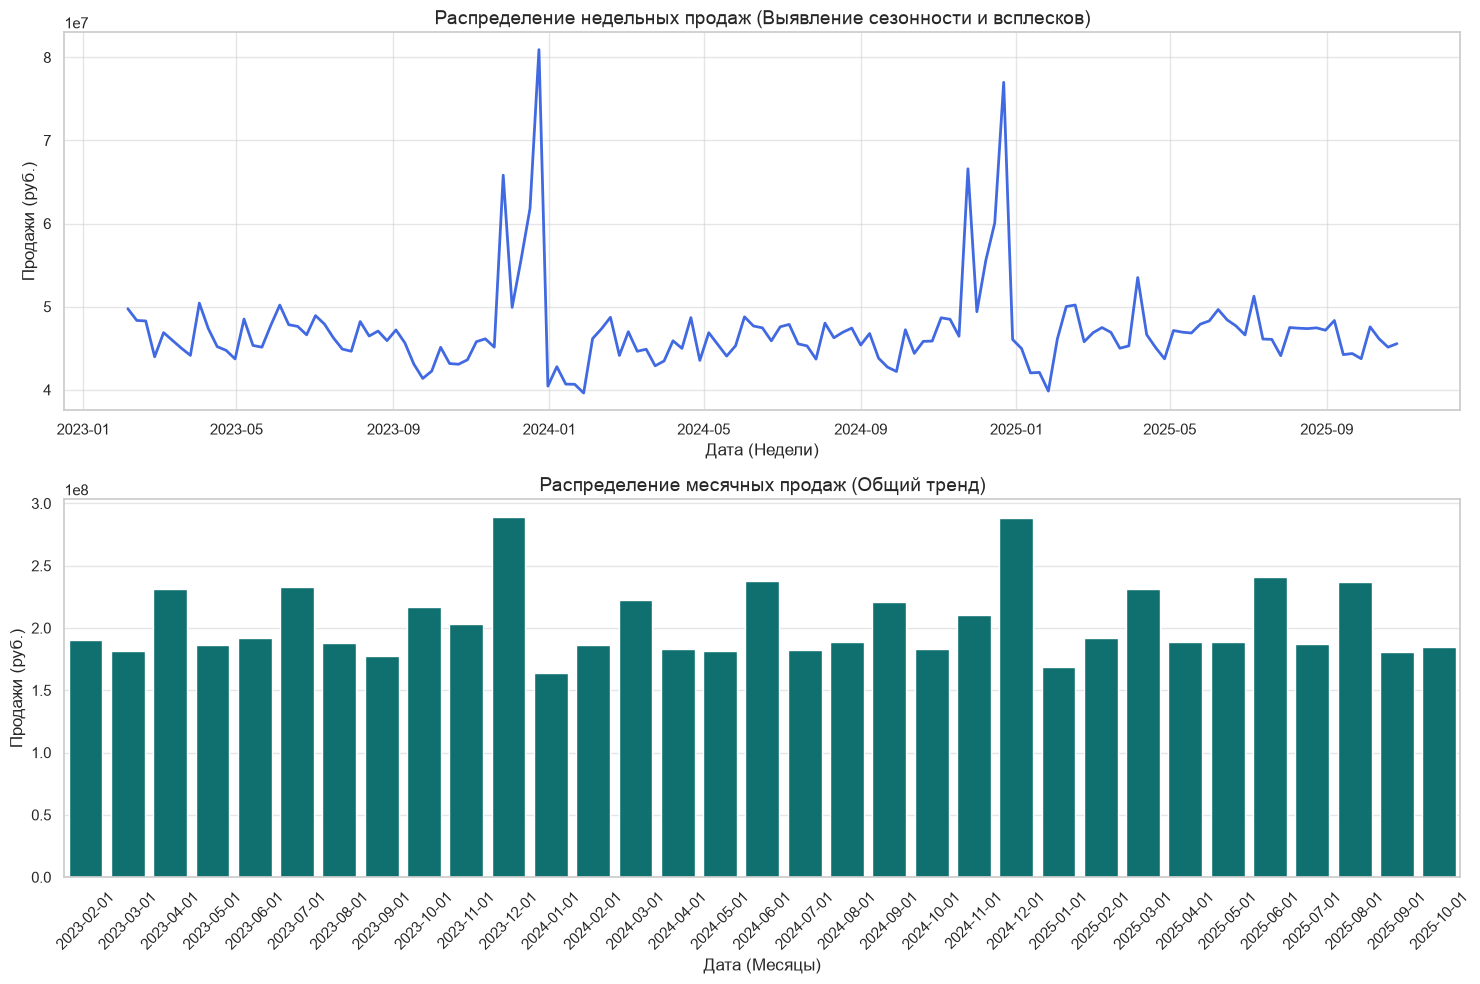

In [11]:
sales_df['date'] = pd.to_datetime(sales_df['date'])
weekly_sales = sales_df.groupby('date')['weekly_sales'].sum().reset_index()
sales_df['month'] = sales_df['date'].dt.to_period('M')
monthly_sales = sales_df.groupby('month')['weekly_sales'].sum().reset_index()
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.lineplot(data=weekly_sales, x='date', y='weekly_sales', color='royalblue', linewidth=2)
plt.title('Распределение недельных продаж (Выявление сезонности и всплесков)', fontsize=14)
plt.xlabel('Дата (Недели)', fontsize=12)
plt.ylabel('Продажи (руб.)', fontsize=12)

plt.subplot(2, 1, 2)
sns.barplot(data=monthly_sales, x='month', y='weekly_sales', color='teal')
plt.title('Распределение месячных продаж (Общий тренд)', fontsize=14)
plt.xlabel('Дата (Месяцы)', fontsize=12)
plt.ylabel('Продажи (руб.)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# Приводим дату в features_df к datetime для корректного merge
features_df['date'] = pd.to_datetime(features_df['date'])

# Шаг 1: Объединяем продажи с информацией о дарксторах
df = pd.merge(sales_df, stores_df, on='store', how='left')

# Шаг 2: Добавляем внешние факторы (features)
# Объединяем по store, dept и date
df = pd.merge(df, features_df, on=['store', 'dept', 'date'], how='left')

# Проверяем финальную структуру
print("Формат итогового датасета:", df.shape)
print("\nПервые 5 строк объединенной таблицы:")
df.head()

Формат итогового датасета: (421570, 17)

Первые 5 строк объединенной таблицы:


,store,dept,date,weekly_sales,is_holiday,month,type,size,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,24924.50,False,2023-02,A,151315,42.31,2.572,7028.8,NaN,NaN,NaN,NaN,211.096358,8.106
1,29,5,2023-02-05,15552.08,False,2023-02,B,93638,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
2,29,6,2023-02-05,3200.22,False,2023-02,B,93638,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
3,29,7,2023-02-05,10820.05,False,2023-02,B,93638,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
4,29,8,2023-02-05,20055.64,False,2023-02,B,93638,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064


### Матрица корреляций

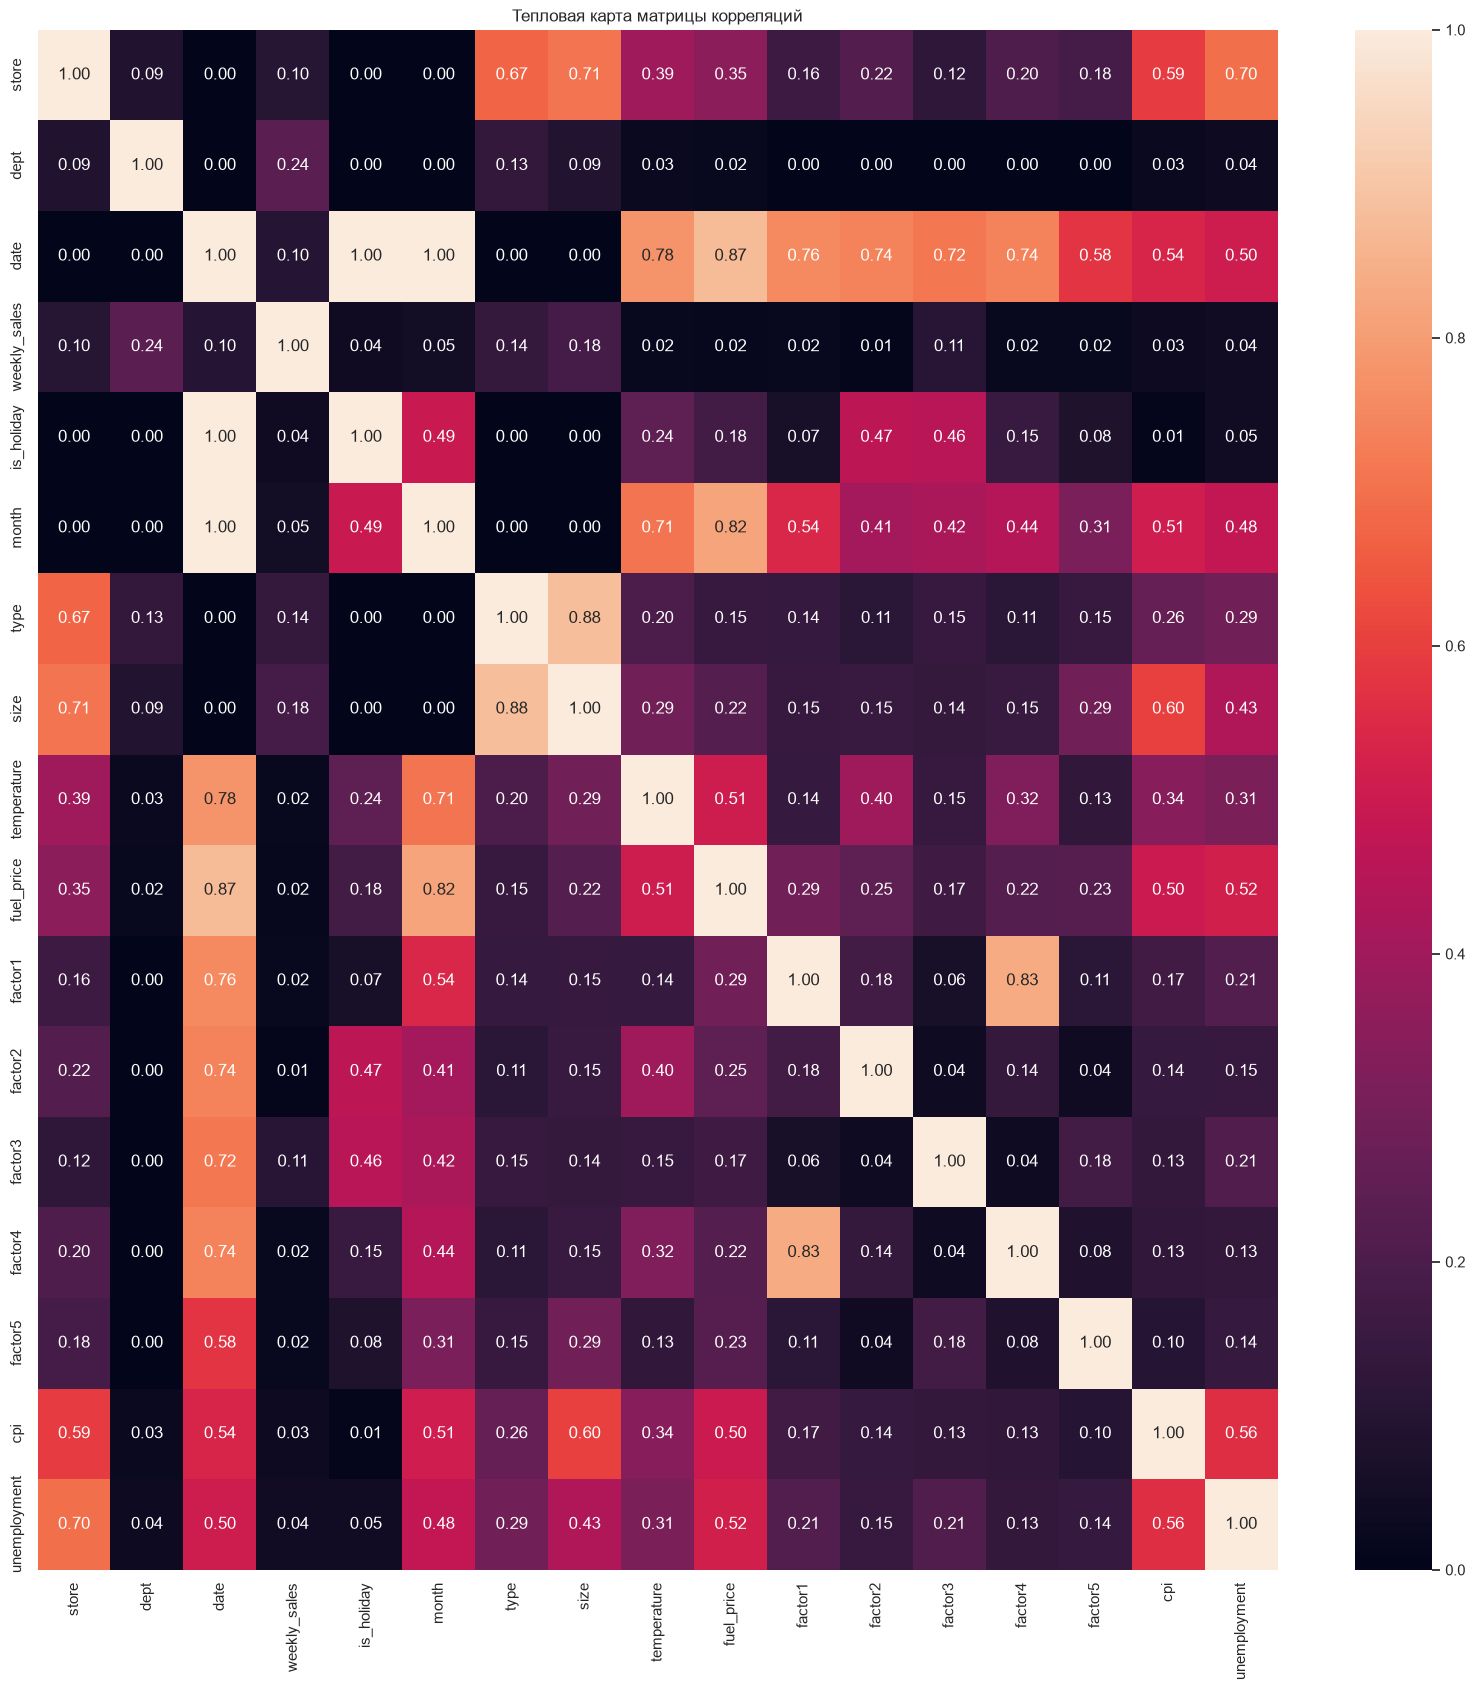

In [13]:
matrix = df.phik_matrix(interval_cols=df.select_dtypes(include=['float','int']).columns)
plt.figure(figsize=(20,20))
sns.heatmap(data=matrix, fmt='.2f',annot=True)
plt.title('Тепловая карта матрицы корреляций')
plt.show()

**обработка аномалий в продажах.**

In [14]:
negative_sales = sales_df[sales_df['weekly_sales'] <= 0]
print(f"Количество строк с продажами <= 0: {len(negative_sales)}")
print(f"Процент от общего объема данных: {len(negative_sales) / len(sales_df) * 100:.4f}%")
print("\nПример таких записей:")
print(negative_sales.head())

Количество строк с продажами <= 0: 1358
Процент от общего объема данных: 0.3221%

Пример таких записей:
      store  dept       date  weekly_sales  is_holiday    month
190      31    78 2023-02-05        -12.00       False  2023-02
267      30    32 2023-02-05        -12.99       False  2023-02
545      26    54 2023-02-05        -34.00       False  2023-02
1419     11    19 2023-02-05          0.00       False  2023-02
1817      6    47 2023-02-05        -59.00       False  2023-02


In [15]:
sales_clean_df = sales_df[sales_df['weekly_sales'] > 0].copy()
print(f"Размер датасета после удаления отрицательных продаж: {sales_clean_df.shape[0]}")

Размер датасета после удаления отрицательных продаж: 420212


In [16]:
quantile_threshold = sales_clean_df['weekly_sales'].quantile(0.9999)
print(f"Порог для топ-0.01% продаж: {quantile_threshold:,.2f} руб.")
high_sales_anomalies = sales_clean_df[sales_clean_df['weekly_sales'] > quantile_threshold].copy()
print(f"Количество записей в топе: {len(high_sales_anomalies)}")

Порог для топ-0.01% продаж: 285,125.75 руб.
Количество записей в топе: 43


In [17]:
high_sales_rich = high_sales_anomalies.merge(stores_df, on='store', how='left')
high_sales_rich['date'] = pd.to_datetime(high_sales_rich['date'])
high_sales_rich['month'] = high_sales_rich['date'].dt.month
high_sales_rich['year'] = high_sales_rich['date'].dt.year

In [18]:
print("Распределение пиковых продаж по месяцам:")
print(high_sales_rich['month'].value_counts().sort_index())

print("\nСвязь с праздничными неделями (is_holiday):")
print(high_sales_rich['is_holiday'].value_counts(normalize=True) * 100)

Распределение пиковых продаж по месяцам:
month
2      1
11    31
12    11
Name: count, dtype: int64

Связь с праздничными неделями (is_holiday):
is_holiday
True     72.093023
False    27.906977
Name: proportion, dtype: float64


In [ ]:
print("Какого типа дарксторы чаще генерят сверхвыручку?")
print(high_sales_rich['type'].value_counts())

print("\nТоп-5 отделов (dept) с аномально высокими продажами:")
print(high_sales_rich['dept'].value_counts().head(5))

### Шаг 2. Предобработка признаков и feature engineering

In [ ]:
df = create_temporal_features(df)

assert 'month' in df.columns, 'Месяц не создан!'
assert 'quarter' in df.columns, 'Квартал не создан!'
assert 'year' in df.columns, 'Год не создан!'

df = create_avg_sales_feature(df)

assert 'avg_sales_before' in df.columns, 'Признак средних продаж не создан!'

df = create_lag_features(df)

assert 'sales_1week_ago' in df.columns, 'Признак sales_1week_ago не создан!'
assert 'sales_2week_ago' in df.columns, 'Признак sales_2week_ago не создан!'
assert 'sales_4week_ago' in df.columns, 'Признак sales_4week_ago не создан!'

df = create_rolling_features(df)

assert 'mean_sales_2week' in df.columns, 'Признак mean_sales_2week не создан!'
assert 'mean_sales_4week' in df.columns, 'Признак mean_sales_4week не создан!'

**удаляем строки с пропусками.**

In [28]:
lag_cols = ['avg_sales_before', 'sales_1week_ago', 'sales_2week_ago', 'sales_4week_ago', 'mean_sales_2week', 'mean_sales_4week']
print("Пропуски в новых признаках до очистки:")
print(df[lag_cols].isna().sum())

print(f"\nРазмер датасета ДО удаления пропусков: {df.shape}")
df.dropna(subset=lag_cols, inplace=True)
print(f"Размер датасета ПОСЛЕ удаления пропусков: {df.shape}")

df.reset_index(drop=True, inplace=True)

Пропуски в новых признаках до очистки:
avg_sales_before     3331
sales_1week_ago      3331
sales_2week_ago      6625
sales_4week_ago     13134
mean_sales_2week     6625
mean_sales_4week    13134
dtype: int64

Размер датасета ДО удаления пропусков: (421570, 25)
Размер датасета ПОСЛЕ удаления пропусков: (408436, 25)


### Шаг 3. Мониторинг стабильности признаков

In [29]:
df = df.sort_values('date').reset_index(drop=True)

train_df = df[df['date'] < '2025-09-01'].copy()
val_df = df[(df['date'] >= '2025-09-01') & (df['date'] <= '2025-10-31')].copy()

print(f"Обучение (Train): {train_df['date'].min().strftime('%Y-%m-%d')} — {train_df['date'].max().strftime('%Y-%m-%d')} | Строк: {len(train_df)}")
print(f"Валидация (Validation): {val_df['date'].min().strftime('%Y-%m-%d')} — {val_df['date'].max().strftime('%Y-%m-%d')} | Строк: {len(val_df)}")

Обучение (Train): 2023-03-05 — 2025-08-31 | Строк: 384726
Валидация (Validation): 2025-09-07 — 2025-10-26 | Строк: 23710


### Расчет PSI

In [31]:
all_columns = train_df.columns.tolist()

excluded_cols = ['weekly_sales', 'date', 'year']
features_to_check = [col for col in all_columns if col not in excluded_cols]

psi_results = {}

for col in features_to_check:
    if train_df[col].dtype == 'object' or train_df[col].dtype == 'bool':
        actual_values = train_df[col].astype('category').cat.codes.values
        expected_values = val_df[col].astype('category').cat.codes.values
    else:
        actual_values = train_df[col].values
        expected_values = val_df[col].values
        
    psi_val = calculate_psi(actual_values, expected_values, num_buckets=10)
    psi_results[col] = psi_val

psi_df = pd.DataFrame(list(psi_results.items()), columns=['Признак (Feature)', 'PSI']).sort_values(by='PSI', ascending=False)

psi_df['Статус'] = psi_df['PSI'].apply(interpret_psi)

print(f"Всего проверено признаков: {len(psi_df)}")
print(psi_df.to_string(index=False))

Всего проверено признаков: 22
Признак (Feature)      PSI                                             Статус
            month 6.476829 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
          quarter 4.555441 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
       fuel_price 4.203073 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
          factor5 2.929260 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
              cpi 2.703802 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
          factor3 1.950177 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
          factor1 1.905381 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
          factor4 1.495420 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
      temperature 0.938354 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
          factor2 0.645653 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
     unemployment 0.406100 PSI ≥ 0.2 — значительный дрейф, признак нестабилен
  sales_4week_ago 0.002350        

In [32]:
bad_features = [
    'month',
    'quarter',
    'fuel_price',
    'factor5',
    'cpi',
    'factor3',
    'factor1',
    'factor4',
    'temperature',
    'factor2',
    'unemployment',
    'is_holiday'
]

train_df_cleaned = train_df.drop(columns=bad_features, errors='ignore')

val_df_cleaned = val_df.drop(columns=bad_features, errors='ignore')

print("Осталось признаков в Train:", train_df_cleaned.shape[1] - 2) # минусуем таргет и дату
print("Оставшиеся колонки:", train_df_cleaned.columns.tolist())

Осталось признаков в Train: 11
Оставшиеся колонки: ['store', 'dept', 'date', 'weekly_sales', 'type', 'size', 'year', 'avg_sales_before', 'sales_1week_ago', 'sales_2week_ago', 'sales_4week_ago', 'mean_sales_2week', 'mean_sales_4week']


### Шаг 4. Обучение модели CatBoost

In [34]:
X_train = train_df_cleaned.drop(columns=['weekly_sales', 'date'], errors='ignore')
y_train = train_df_cleaned['weekly_sales']

X_val = val_df_cleaned.drop(columns=['weekly_sales', 'date'], errors='ignore')
y_val = val_df_cleaned['weekly_sales']

cat_features = [col for col in ['store', 'dept', 'type'] if col in X_train.columns]
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    early_stopping_rounds=50
)

0:	learn: 21770.1216504	total: 412ms	remaining: 6m 51s
100:	learn: 5760.2562528	total: 51.8s	remaining: 7m 40s
200:	learn: 5532.9011595	total: 1m 37s	remaining: 6m 27s
300:	learn: 5391.0283203	total: 2m 24s	remaining: 5m 35s
400:	learn: 5262.5475986	total: 3m 9s	remaining: 4m 43s
500:	learn: 5165.6777602	total: 3m 54s	remaining: 3m 53s
600:	learn: 5078.5369844	total: 4m 42s	remaining: 3m 7s
700:	learn: 5002.4679799	total: 5m 28s	remaining: 2m 20s
800:	learn: 4931.1488939	total: 6m 16s	remaining: 1m 33s
900:	learn: 4876.7087081	total: 7m 1s	remaining: 46.3s
999:	learn: 4820.5920464	total: 7m 48s	remaining: 0us


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [35]:
y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("--- Метрики качества на валидационной выборке ---")
print(f"MAE:  {mae:,.2f} руб.")
print(f"RMSE: {rmse:,.2f} руб.")
print(f"R²:   {r2:.4f}")
print("-" * 50)

--- Метрики качества на валидационной выборке ---
MAE:  1,387.06 руб.
RMSE: 2,950.11 руб.
R²:   0.9817
--------------------------------------------------


## Важность признаков.


In [36]:
importance = model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность (%)': importance
}).sort_values(by='Важность (%)', ascending=False)

print("\n--- Важность признаков для модели ---")
print(feature_importance_df.to_string(index=False))


--- Важность признаков для модели ---
         Признак  Важность (%)
 sales_1week_ago     33.995294
mean_sales_2week     18.003434
mean_sales_4week     15.558859
 sales_4week_ago     12.733253
avg_sales_before      9.903967
 sales_2week_ago      4.715755
            dept      2.495672
            year      0.956482
           store      0.791661
            size      0.544655
            type      0.300968


### Сохранение модели в S3

In [37]:
import io
import os
import pickle
import boto3
from dotenv import load_dotenv

load_dotenv()
cb = model
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

filebuffer = io.BytesIO()
pickle.dump(cb, filebuffer)
filebuffer.seek(0)
bucket_name = os.getenv('S3_BUCKET')

s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=bucket_name,
    Key='catboost_model.pkl'  
)

print(f"Модель успешно загружена в {bucket_name}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260504-f859d302ee/catboost_model1.pkl
